### Features I would like

In [1]:
import numpy as np
from qutip import *
import matplotlib.pyplot as plt
from fluxonium_classes import *

In [2]:
e = 1.602*10**(-19)
h = 6.626*10**(-34)
phi_0 = h/(2*e)
unit_fF_inv_to_GHz = e**2 /h * 10**6
unit_nH_inv_to_GHz = 1/h * (phi_0/(2*np.pi))**2

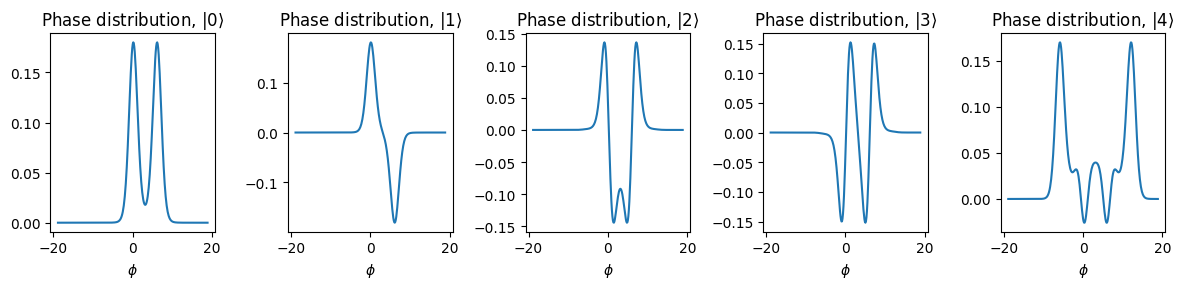

In [2]:

# from Zhang, Chicago paper 2021, all in GHz
E_L = 0.132
C_J = 2 #fF
C = 38 #fF, want to satisfy E_C = 0.479 GHz
E_J = 3.395

N_wavfuncs = 5
ext_phase = np.pi

flux1 = Fluxonium(E_J, C_J, C, E_L)
flux1.plot_wavefuncs(N_wavfuncs, ext_phase)

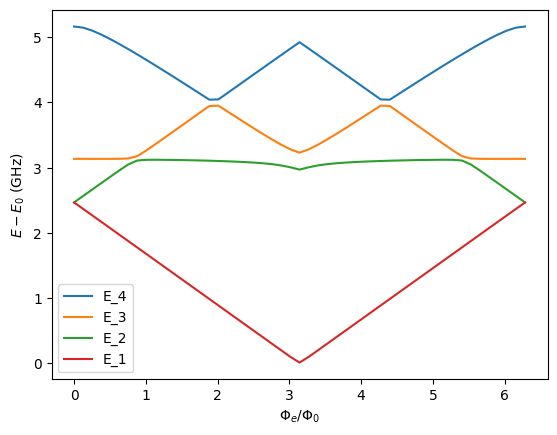

In [3]:
N_en_levels = 5
N_flux = 51
ext_phase = np.linspace(0, 2*np.pi, N_flux)
flux1.plot_transistions_over_flux(ext_phase, N_en_levels)
plt.legend()

In [6]:
resonator_list = []
cap_mat_list = []

gammas = np.linspace(0.5, 1.5, 5)
Cr = 300 #fF
Lr = 5 #nH
fock_dim = 6

Cg = 10 # fF

N_flux = 11
ext_phase = np.linspace(np.pi - 1, np.pi + 1, N_flux)

for gamma in gammas:
    res = Resonator(Cr, Lr, fock_dim)
    resonator_list.append(res)

    cap_mat = np.matrix([

                [C+C_J + Cg, -Cg],

                [-Cg, Cg + Cr]

            ])
    
    cap_mat_list.append(cap_mat)

flux1.add_resonator_coupling(resonator_list, cap_mat_list)
chis = flux1.find_chi_full(1, ext_phase)